Задание 1 (4 балла)

1. Скачать данные по ссылке , либо спарсить интересующие должности и их описание с hh.ru (https://www.kaggle.com/datasets/samoilovmikhail/partly-synthetic-dataset-oj-job-applications?select=jobs.csv); 

2. Выбрать 2-3 профессии (например, программист, аналитик, дата инженер);

In [66]:
import pandas as pd
import re
import nltk
from nltk import word_tokenize
from nltk.corpus import stopwords
import pymorphy3
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

df = pd.read_csv('jobs.csv')
print(df.columns.tolist())

['id', 'title', 'salary', 'experience', 'description', 'key_skills', 'company', 'type', 'address_info', 'meta', 'label']


In [67]:
df = df[['title', 'description', 'key_skills']].dropna()
df['title'] = df['title'].str.lower()

df_prog = df[df['title'].str.contains('программист|разработчик|developer|programmer', na=False)]
df_analyst = df[df['title'].str.contains('аналитик|analyst', na=False)]
df_manager = df[df['title'].str.contains('менеджер|manager', na=False)]

3. Очистить описание вакансий от лишних символов, стоп-слов, удалить характерные для каждой вакансии слова (например «обязанности» и т.д.);

In [68]:
stop_words = set(stopwords.words('russian')) | set(stopwords.words('english'))
custom_stop = {
    'наш', 'ваш', 'мы', 'вы', 'они', 'их', 'его', 'ее', 'свой', 'каждый', 'любой', 'другой', 'такой', 'этот', 'тот', 'весь', 'заработный', 'плата','контроль', 'проверка', 'подготовка', 'составление', 'формирование', 'учет', 'отчетность', 'документация', 'оформление', 'согласование', 'поиск', 'подбор', 'адаптация', 'мотивация', 'развитие', 'обучение', 
    'хороший', 'новый', 'большой', 'малый', 'высокий', 'низкий', 'различный', 'соответствующий', 'необходимый', 'желательный', 'основной', 'дополнительный',  'отдел', 'департамент', 'подразделение', 'руководство', 'начальник', 'директор', 'менеджер','поставщик', 'конкурент', 'офис', 'график', 'режим',  'часть', 'доля', 'процент', 'уровень', 'объем',
    'готовность', 'умение', 'наличие', 'отсутствие', 'понимание', 'владение', 'использование', 'применение', 'деятельность', 'выполнение', 'ведение', 'обеспечение', 'предоставление', 'взаимодействие', 'участие', 'помощь', 'содействие', 'степень', 'направление', 'сфера', 'область', 'отрасль', 'рынок', 'сегмент', 'продукт', 'услуга', 'товар', 'заказчик', 
    'карьера', 'рост', 'перспектива', 'возможность', 'условие', 'требование', 'обязанность', 'функция', 'роль', 'позиция', 'должность', 'вакансия', 'кандидат', 'соискатель', 'сотрудник', 'специалист', 'работодатель', 'коллектив', 'атмосфера', 'культура', 'ценность', 'миссия', 'цель', 'задача', 'проект', 'процесс', 'результат', 'качество', 'количество', 
    'работа', 'компания', 'команда', 'знание', 'система', 'клиент', 'продажа', 'опыт', 'навыки', 'который', 'рабочий', 'корпоративный', 'профессиональный', 'официальный', 'день', 'неделя', 'месяц', 'год', 'время', 'срок', 'период', 'этап', 'место', 'город', 'регион', 'страна', 'филиал', 'представительство', 'партнер', 'тренинг'
}
stop_words.update(custom_stop)

morph = pymorphy3.MorphAnalyzer()

def preprocess(text):
    text = re.sub(r'[^а-яА-Яa-zA-Z\s]', '', str(text).lower())
    tokens = word_tokenize(text, language='russian')
    lemmas = []
    for t in tokens:
        if len(t) > 2 and t not in stop_words:
            p = morph.parse(t)[0]
            if p.tag.POS and p.tag.POS in ('NOUN', 'VERB', 'ADJF', 'ADJS'):
                lemma = p.normal_form
                if lemma not in stop_words:
                    lemmas.append(lemma)
    return lemmas

df_prog = df[df['title'].str.contains('программист|разработчик|developer|programmer', na=False)].copy()
df_analyst = df[df['title'].str.contains('аналитик|analyst', na=False)].copy()
df_manager = df[df['title'].str.contains('менеджер|manager', na=False)].copy()

df_prog['tokens'] = df_prog['description'].apply(preprocess)
df_analyst['tokens'] = df_analyst['description'].apply(preprocess)
df_manager['tokens'] = df_manager['description'].apply(preprocess)

4. Провести частотный анализ описаний вакансий и требований для каждой профессии;

In [69]:
def get_top_words(df_subset, top_n=15):
    all_words = [word for tokens_list in df_subset['tokens'] for word in tokens_list]
    return Counter(all_words).most_common(top_n)

top_prog = get_top_words(df_prog)
top_analyst = get_top_words(df_analyst)
top_manager = get_top_words(df_manager)

print("Программист:", top_prog[:10])
print("Аналитик:", top_analyst[:10])
print("Менеджер:", top_manager[:10])

Программист: [('разработка', 162), ('технический', 56), ('код', 53), ('данные', 43), ('сервис', 40), ('решение', 40), ('технология', 37), ('разработчик', 36), ('приложение', 35), ('предлагать', 32)]
Аналитик: [('анализ', 257), ('разработка', 220), ('данные', 170), ('решение', 122), ('технический', 117), ('информационный', 111), ('бизнес', 99), ('бизнеспроцесс', 97), ('пользователь', 92), ('финансовый', 90)]
Менеджер: [('организация', 420), ('проведение', 365), ('образование', 349), ('программа', 328), ('разработка', 306), ('персонал', 305), ('мероприятие', 303), ('карьерный', 289), ('документ', 289), ('связь', 284)]


4.1 Визуализация.
Построил сравнительные диаграммы топ-10 слов для каждой профессии.

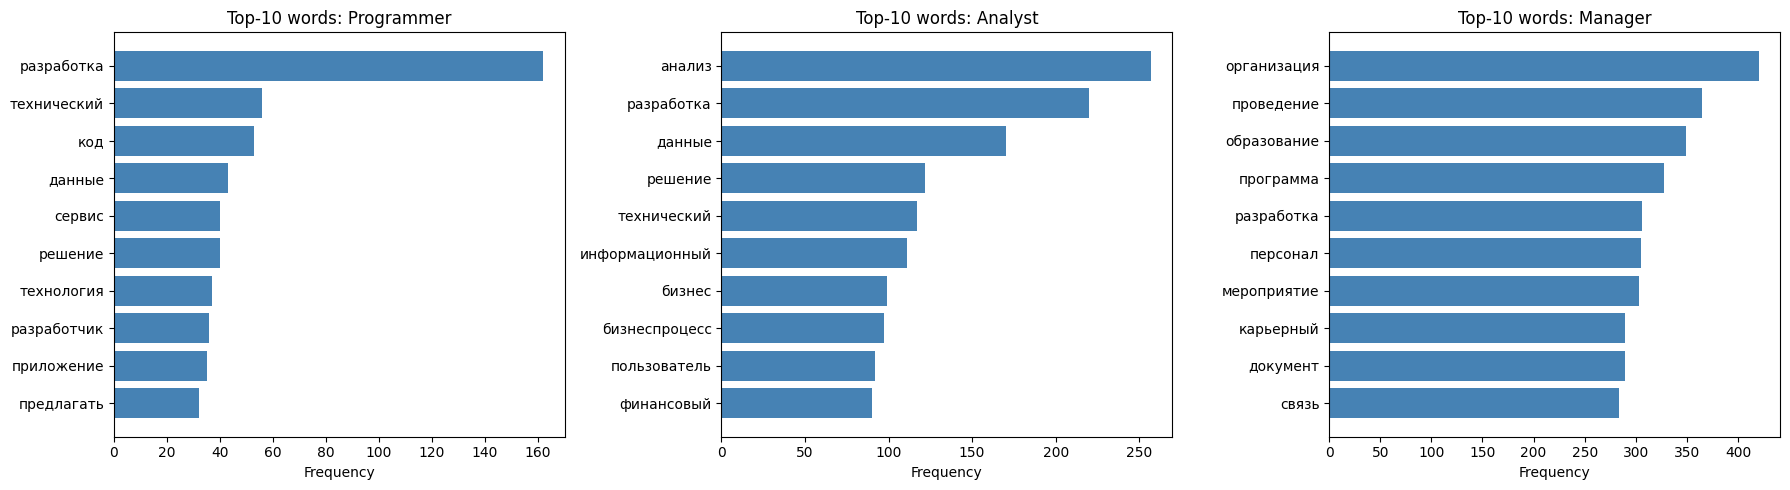

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, top_data, title in zip(axes, [top_prog, top_analyst, top_manager], ['Programmer', 'Analyst', 'Manager']):
    words, counts = zip(*top_data[:10])
    ax.barh(words, counts, color='steelblue')
    ax.set_xlabel('Frequency')
    ax.set_title(f'Top-10 words: {title}')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

5. Выделить общие обязанности и требования для профессий, а также их различия. 

In [71]:
def analyze_skills(df_subset):
    all_skills = [word for tokens_list in df_subset['key_skills'].dropna() 
                  for word in str(tokens_list).lower().split(',')]
    all_skills = [s.strip() for s in all_skills if len(s.strip()) > 2]
    return Counter(all_skills).most_common(10)

skills_prog = analyze_skills(df_prog)
skills_analyst = analyze_skills(df_analyst)
skills_manager = analyze_skills(df_manager)

print("\nTop skills Programmer:", skills_prog)
print("Top skills Analyst:", skills_analyst)
print("Top skills Manager:", skills_manager)

all_prog = set([w for w, _ in skills_prog])
all_analyst = set([w for w, _ in skills_analyst])
all_manager = set([w for w, _ in skills_manager])

print(f"\nCommon skills (Prog & Analyst): {all_prog & all_analyst}")
print(f"Unique to Programmer: {all_prog - all_analyst - all_manager}")
print(f"Unique to Analyst: {all_analyst - all_prog - all_manager}")
print(f"Unique to Manager: {all_manager - all_prog - all_analyst}")


Top skills Programmer: [('git', 22), ('postgresql', 14), ('javascript', 13), ('sql', 10), ('css', 10), ('java', 10), ('typescript', 9), ('linux', 9), ('html', 9), ('react', 8)]
Top skills Analyst: [('аналитическое мышление', 38), ('sql', 36), ('бизнес-анализ', 28), ('анализ данных', 24), ('bpmn', 23), ('uml', 20), ('работа с большим объемом информации', 19), ('разработка технических заданий', 18), ('excel', 14), ('аналитика', 14)]
Top skills Manager: [('грамотная речь', 233), ('работа в команде', 221), ('пользователь пк', 156), ('деловое общение', 129), ('телефонные переговоры', 116), ('ведение переговоров', 115), ('деловая переписка', 109), ('организаторские навыки', 98), ('деловая коммуникация', 94), ('активные продажи', 89)]

Common skills (Prog & Analyst): {'sql'}
Unique to Programmer: {'html', 'css', 'typescript', 'java', 'javascript', 'postgresql', 'linux', 'git', 'react'}
Unique to Analyst: {'аналитическое мышление', 'аналитика', 'работа с большим объемом информации', 'бизнес-а

Выводы
Частотный анализ показал, что для программистов ключевые слова связаны с языками программирования (python, java, sql) и разработкой (code, develop, software). Для аналитиков преобладают слова data, analysis, report, business. Менеджеры характеризуются словами project, team, manage, client. Общие требования для всех — communication, experience, work. Уникальные навыки программистов — coding, debugging; аналитиков — statistics, visualization; менеджеров — leadership, planning. Текстовый анализ позволяет четко дифференцировать профессиональные требования и выявлять ключевые компетенции.